In [1]:
import yaml
with open('neuron_models.yaml', 'r') as f:
    neuron_models_dict = yaml.load(f)
with open('neuron_parameters.yaml', 'r') as f:
    neuron_params_dict = yaml.load(f)
with open('synapse_models.yaml', 'r') as f:
    synapse_models_dict = yaml.load(f)
with open('synapse_parameters.yaml', 'r') as f:
    synapse_params_dict_dict = yaml.load(f)

print(neuron_models_dict['Spencer2009_neuron']['eqs'])
print(neuron_params_dict['Pyramidal_Cells'])
print(synapse_models_dict['AMPA'])
print(synapse_params_dict_dict['AMPA']['Pyramidal_Cells']['Pyramidal_Cells'])

dV/dt = (-g_m*(V-V_res) + I_syn)/C_m : volt
 I_syn = I_AMPA + I_NMDA + I_GABA : ampere
 I_AMPA = g_AMPA*(V-V_E) : ampere
 I_NMDA = g_NMDA*(V-V_E)/(1.0+C_Mg*exp(-0.062*V/mV)/3.57) : ampere
 I_GABA = g_GABA*(V-V_I) : ampere
 g_AMPA : siemens
 g_NMDA : siemens
 g_GABA : siemens

{'N': 800, 'eqs': 'Spencer2009_neuron', 'threshold': 'V>-52*mV', 'reset': 'V=-59*mV', 'namespace': {'g_m': '25*nS', 'C_m': '0.5*nF', 'V_res': '-70*mV', 'V_E': '0*mV', 'V_I': '-70*mV', 'C_Mg': '1.0'}}
{'model': ' g_AMPA_post = scl*(g_r + g_d)/norm : siemens (summed)\n dg_r/dt = -g_r/tau_r + noise : siemens (clock-driven)\n dg_d/dt = -g_d/tau_d + noise : siemens (clock-driven)\n ', 'on_pre': ' g_r += w\n g_d += w\n ', 'namespace': {'norm': '0.472689', 'tau_r': '0.5*ms', 'tau_d': '20*ms', 'noise': '0*uS/ms'}}
{'p': 0.1, 'namespace': {'w': '825*nS', 'scl': '1'}}
/home/yi/.local/lib/python3.6/site-packages/ipykernel_launcher.py:3: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loa

In [2]:
import brian2
brian2.start_scope()
#load neurons
groups_dict = dict()
for name, params in neuron_params_dict.items():
    params['namespace'] = {n:eval(q, brian2.core.namespace.DEFAULT_UNITS) for n, q in params['namespace'].items()}
    neuron_eqs = neuron_models_dict[params.pop('eqs')]['eqs']
    groups_dict[name] = brian2.NeuronGroup(params.pop('N'), neuron_eqs, name=name, **params)

In [3]:
#load synapse
import itertools
for synapse_name, synapse_model in synapse_models_dict.items():
    synapse_model_namespace = synapse_model.pop('namespace')
    for from_neuron_name, synapse_params_dict in synapse_params_dict_dict[synapse_name].items():
        for to_neuron_name, synapse_params in synapse_params_dict.items():
            namespace = {n:eval(q, brian2.core.namespace.DEFAULT_UNITS) for n, q in itertools.chain(synapse_model_namespace.items(), synapse_params.pop('namespace').items())}
            synapse = brian2.Synapses(
                groups_dict['Pyramidal_Cells'], groups_dict['Pyramidal_Cells'],
                name=synapse_name, namespace=namespace, **synapse_model
            )
            synapse.connect(**synapse_params)

INFO       No numerical integration method specified for group 'GABA', using method 'exact' (took 0.60s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'Pyramidal_Cells', using method 'euler' (took 0.02s, trying other methods took 0.13s). [brian2.stateupdaters.base.method_choice]


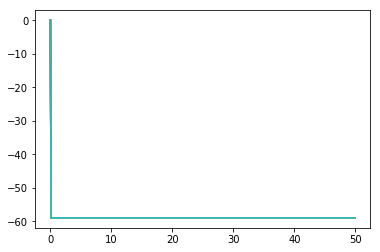

In [4]:
import matplotlib.pyplot as plt

G = groups_dict['Pyramidal_Cells']
M = brian2.StateMonitor(G, 'V', record=list(range(10)))
brian2.run(50*brian2.ms)
for n in range(10):
    plt.plot(M.t/brian2.ms, M.V[n]/brian2.mV)